# Spatial Resolution Demo with STAC

This notebook searches public STAC APIs for Landsat Collection 2 Level 2 and Sentinel-2 Level 2A imagery covering the full extent of `tarkine_south.geojson`. Sentinel-2 is queried from Earth Search, while Landsat is queried from the Microsoft Planetary Computer so the notebook can use signed download URLs instead of requester-pays S3 objects. The workflow ranks candidate scenes by proximity to `2025-04-30` after applying a platform-specific cloud-cover threshold, downloads only the red, green, and blue assets, builds RGB mosaics clipped to the AOI extent, and plots the two outputs side by side for a spatial-resolution comparison.

The `eo:cloud_cover` property is scene-level metadata rather than an AOI-specific cloud mask, so the selected dates are the nearest low-cloud scenes available for the whole scene footprint.

In [7]:
from collections import defaultdict
from contextlib import ExitStack
from datetime import date, timedelta
from pathlib import Path
from urllib.request import urlopen

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import planetary_computer
import rasterio
from pystac_client import Client
from rasterio.enums import Resampling
from rasterio.merge import merge
from rasterio.plot import reshape_as_image
from shapely.geometry import shape
from shapely.ops import unary_union

TARGET_DATE = date(2025, 4, 30)
SEARCH_WINDOW_DAYS = 75
AOI_PATH = Path("../data/vector/tarkine_south.geojson")
EARTH_SEARCH_URL = "https://earth-search.aws.element84.com/v1"
PLANETARY_COMPUTER_URL = "https://planetarycomputer.microsoft.com/api/stac/v1"
OUTPUT_ROOT = Path("../outputs/spatial_resolution_demo")
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

PLATFORMS = {
    "landsat": {
        "collection": "landsat-c2-l2",
        "stac_url": PLANETARY_COMPUTER_URL,
        "assets": {"red": "red", "green": "green", "blue": "blue"},
        "max_cloud_cover": 20.0,
        "sign_assets": True,
    },
    "sentinel-2": {
        "collection": "sentinel-2-c1-l2a",
        "stac_url": EARTH_SEARCH_URL,
        "assets": {"red": "red", "green": "green", "blue": "blue"},
        "max_cloud_cover": 10.0,
        "sign_assets": False,
    },
}

In [2]:
aoi = gpd.read_file(AOI_PATH)
aoi_4326 = aoi.to_crs(4326)
aoi_geom = aoi_4326.dissolve().geometry.iloc[0].buffer(0)
aoi_bounds_4326 = tuple(aoi_4326.total_bounds)
search_start = TARGET_DATE - timedelta(days=SEARCH_WINDOW_DAYS)
search_end = TARGET_DATE + timedelta(days=SEARCH_WINDOW_DAYS)

print(f"AOI path: {AOI_PATH.resolve()}")
print(f"AOI bounds in EPSG:4326: {aoi_bounds_4326}")
print(f"Search window: {search_start.isoformat()} to {search_end.isoformat()}")
aoi_4326[["name", "geometry"]]

AOI path: /home/peterj7/repos/tassie-trees-research-plan/data/vector/tarkine_south.geojson
AOI bounds in EPSG:4326: (np.float64(145.28955949954184), np.float64(-41.710616377836885), np.float64(145.39485727567205), np.float64(-41.60832194097826))
Search window: 2025-02-14 to 2025-07-14


,name,geometry
0,Harman River,"POLYGON ((145.35487 -41.69977, 145.37629 -41.6..."
1,Stanley River,"POLYGON ((145.31799 -41.63044, 145.29712 -41.6..."
2,Wilson River,"POLYGON ((145.39486 -41.63241, 145.36463 -41.6..."


In [8]:
CLIENTS = {}


def get_client(stac_url):
    if stac_url not in CLIENTS:
        CLIENTS[stac_url] = Client.open(stac_url)
    return CLIENTS[stac_url]


def scene_cloud_cover(item):
    return item.properties.get("eo:cloud_cover")


def search_items(config, aoi_geometry, target_date, search_window_days):
    client = get_client(config["stac_url"])
    date_range = (
        f"{target_date - timedelta(days=search_window_days):%Y-%m-%d}/"
        f"{target_date + timedelta(days=search_window_days):%Y-%m-%d}"
    )
    search = client.search(
        collections=[config["collection"]],
        intersects=aoi_geometry.__geo_interface__,
        datetime=date_range,
        limit=200,
    )
    return list(search.items())


def build_date_groups(items, aoi_geometry, target_date, max_cloud_cover=None):
    grouped = defaultdict(list)
    for item in items:
        if item.datetime is None:
            continue
        cloud_cover = scene_cloud_cover(item)
        if max_cloud_cover is not None and cloud_cover is not None and cloud_cover > max_cloud_cover:
            continue
        grouped[item.datetime.date()].append(item)

    rows = []
    for acquisition_date, day_items in grouped.items():
        footprints = [shape(item.geometry).buffer(0) for item in day_items]
        footprint_union = unary_union(footprints)
        clouds = [scene_cloud_cover(item) for item in day_items if scene_cloud_cover(item) is not None]
        rows.append(
            {
                "date": acquisition_date,
                "days_from_target": abs((acquisition_date - target_date).days),
                "mean_cloud_cover": sum(clouds) / len(clouds) if clouds else None,
                "covers_aoi": footprint_union.covers(aoi_geometry),
                "items": day_items,
            }
        )

    rows.sort(
        key=lambda row: (
            row["days_from_target"],
            row["mean_cloud_cover"] if row["mean_cloud_cover"] is not None else float("inf"),
            len(row["items"]),
        )
    )
    return rows


def greedy_cover(items, aoi_geometry):
    remaining = aoi_geometry
    selected = []
    pool = list(items)
    total_area = aoi_geometry.area

    while pool and not remaining.is_empty and remaining.area / total_area > 1e-6:
        scored = []
        for item in pool:
            gain = shape(item.geometry).buffer(0).intersection(remaining).area
            scored.append((gain, item))
        gain, best_item = max(scored, key=lambda pair: pair[0])
        if gain <= 0:
            break
        selected.append(best_item)
        remaining = remaining.difference(shape(best_item.geometry).buffer(0))
        pool = [item for item in pool if item.id != best_item.id]

    covered = remaining.is_empty or remaining.area / total_area <= 1e-6
    return selected, covered


def prepare_items_for_download(items, config):
    if config.get("sign_assets"):
        return [planetary_computer.sign(item) for item in items]
    return items


def select_scenes(platform_name, config, aoi_geometry, target_date, search_window_days):
    items = search_items(config, aoi_geometry, target_date, search_window_days)
    filtered_groups = [
        group
        for group in build_date_groups(
            items,
            aoi_geometry=aoi_geometry,
            target_date=target_date,
            max_cloud_cover=config["max_cloud_cover"],
        )
        if group["covers_aoi"]
    ]

    used_cloud_fallback = False
    if not filtered_groups:
        filtered_groups = [
            group
            for group in build_date_groups(
                items,
                aoi_geometry=aoi_geometry,
                target_date=target_date,
                max_cloud_cover=None,
            )
            if group["covers_aoi"]
        ]
        used_cloud_fallback = True

    if not filtered_groups:
        raise RuntimeError(f"No {platform_name} date group covers the AOI within the search window.")

    chosen_group = filtered_groups[0]
    selected_items, covered = greedy_cover(chosen_group["items"], aoi_geometry)
    if not covered:
        raise RuntimeError(f"Failed to build full AOI coverage for {platform_name}.")

    return {
        "platform": platform_name,
        "collection": config["collection"],
        "selected_date": chosen_group["date"],
        "days_from_target": chosen_group["days_from_target"],
        "mean_cloud_cover": chosen_group["mean_cloud_cover"],
        "used_cloud_fallback": used_cloud_fallback,
        "selected_items": prepare_items_for_download(selected_items, config),
    }

In [9]:
selections = {}
scene_rows = []

for platform_name, config in PLATFORMS.items():
    selection = select_scenes(
        platform_name=platform_name,
        config=config,
        aoi_geometry=aoi_geom,
        target_date=TARGET_DATE,
        search_window_days=SEARCH_WINDOW_DAYS,
    )
    selections[platform_name] = selection

    for item in selection["selected_items"]:
        scene_rows.append(
            {
                "platform": platform_name,
                "collection": selection["collection"],
                "selected_date": selection["selected_date"].isoformat(),
                "days_from_target": selection["days_from_target"],
                "mean_cloud_cover": selection["mean_cloud_cover"],
                "scene_id": item.id,
                "scene_cloud_cover": scene_cloud_cover(item),
                "cloud_filter_relaxed": selection["used_cloud_fallback"],
            }
        )

scene_summary = pd.DataFrame(scene_rows).sort_values(["platform", "scene_id"]).reset_index(drop=True)
scene_summary

,platform,collection,selected_date,days_from_target,mean_cloud_cover,scene_id,scene_cloud_cover,cloud_filter_relaxed
0,landsat,landsat-c2-l2,2025-05-20,20,15.760000,LC09_L2SP_091089_20250520_02_T1,15.760000,False
1,sentinel-2,sentinel-2-c1-l2a,2025-03-27,34,1.282401,S2C_T55GCP_20250327T001131_L2A,1.282401,False


In [10]:
def download_file(url, destination, chunk_size=1024 * 1024):
    from urllib.parse import urlparse

    import boto3
    from botocore import UNSIGNED
    from botocore.config import Config

    if destination.exists() and destination.stat().st_size > 0:
        return destination

    destination.parent.mkdir(parents=True, exist_ok=True)
    parsed = urlparse(url)

    if parsed.scheme == "s3":
        s3_client = boto3.client("s3", config=Config(signature_version=UNSIGNED))
        bucket = parsed.netloc
        key = parsed.path.lstrip("/")
        with destination.open("wb") as output_file:
            s3_client.download_fileobj(bucket, key, output_file)
        return destination

    with urlopen(url) as response, destination.open("wb") as output_file:
        while True:
            chunk = response.read(chunk_size)
            if not chunk:
                break
            output_file.write(chunk)
    return destination


downloads = defaultdict(lambda: defaultdict(list))
download_rows = []

for platform_name, selection in selections.items():
    platform_dir = OUTPUT_ROOT / platform_name / selection["selected_date"].isoformat()
    for item in selection["selected_items"]:
        item_dir = platform_dir / item.id
        for colour_name, asset_name in PLATFORMS[platform_name]["assets"].items():
            asset = item.assets[asset_name]
            href_without_query = asset.href.split("?", maxsplit=1)[0]
            suffix = Path(href_without_query).suffix or ".tif"
            destination = item_dir / f"{colour_name}{suffix}"
            download_file(asset.href, destination)
            downloads[platform_name][colour_name].append(destination)
            download_rows.append(
                {
                    "platform": platform_name,
                    "scene_id": item.id,
                    "band": colour_name,
                    "path": str(destination),
                }
            )

download_manifest = pd.DataFrame(download_rows).sort_values(["platform", "scene_id", "band"]).reset_index(drop=True)
download_manifest

,platform,scene_id,band,path
0,landsat,LC09_L2SP_091089_20250520_02_T1,blue,../outputs/spatial_resolution_demo/landsat/202...
1,landsat,LC09_L2SP_091089_20250520_02_T1,green,../outputs/spatial_resolution_demo/landsat/202...
2,landsat,LC09_L2SP_091089_20250520_02_T1,red,../outputs/spatial_resolution_demo/landsat/202...
3,sentinel-2,S2C_T55GCP_20250327T001131_L2A,blue,../outputs/spatial_resolution_demo/sentinel-2/...
4,sentinel-2,S2C_T55GCP_20250327T001131_L2A,green,../outputs/spatial_resolution_demo/sentinel-2/...
5,sentinel-2,S2C_T55GCP_20250327T001131_L2A,red,../outputs/spatial_resolution_demo/sentinel-2/...


In [11]:
def build_rgb_mosaic(platform_name, band_paths, aoi_frame, output_root, acquisition_date):
    sample_path = band_paths["red"][0]
    with rasterio.open(sample_path) as sample_src:
        src_meta = sample_src.meta.copy()
        src_crs = sample_src.crs

    aoi_in_src_crs = aoi_frame.to_crs(src_crs)
    bounds = tuple(aoi_in_src_crs.total_bounds)

    merged_bands = []
    transform = None
    for colour_name in ["red", "green", "blue"]:
        with ExitStack() as stack:
            sources = [stack.enter_context(rasterio.open(path)) for path in band_paths[colour_name]]
            mosaic, transform = merge(sources, bounds=bounds, nodata=0)
        merged_bands.append(mosaic[0])

    rgb = np.stack(merged_bands, axis=0)
    output_path = output_root / f"{platform_name}_rgb_{acquisition_date.isoformat()}.tif"

    output_meta = src_meta.copy()
    output_meta.update(
        driver="GTiff",
        height=rgb.shape[1],
        width=rgb.shape[2],
        count=3,
        dtype=rgb.dtype,
        crs=src_crs,
        transform=transform,
        compress="deflate",
        nodata=0,
    )

    with rasterio.open(output_path, "w", **output_meta) as dst:
        dst.write(rgb)

    return output_path


mosaic_paths = {}
mosaic_rows = []

for platform_name, band_paths in downloads.items():
    acquisition_date = selections[platform_name]["selected_date"]
    mosaic_path = build_rgb_mosaic(
        platform_name=platform_name,
        band_paths=band_paths,
        aoi_frame=aoi_4326,
        output_root=OUTPUT_ROOT,
        acquisition_date=acquisition_date,
    )
    mosaic_paths[platform_name] = mosaic_path

    with rasterio.open(mosaic_path) as src:
        mosaic_rows.append(
            {
                "platform": platform_name,
                "mosaic_path": str(mosaic_path),
                "crs": src.crs.to_string(),
                "pixel_size_x": src.res[0],
                "pixel_size_y": abs(src.res[1]),
                "width": src.width,
                "height": src.height,
            }
        )

mosaic_summary = pd.DataFrame(mosaic_rows).sort_values("platform").reset_index(drop=True)
mosaic_summary

,platform,mosaic_path,crs,pixel_size_x,pixel_size_y,width,height
0,landsat,../outputs/spatial_resolution_demo/landsat_rgb...,EPSG:32655,30.0,30.0,287,380
1,sentinel-2,../outputs/spatial_resolution_demo/sentinel-2_...,EPSG:32755,10.0,10.0,860,1141


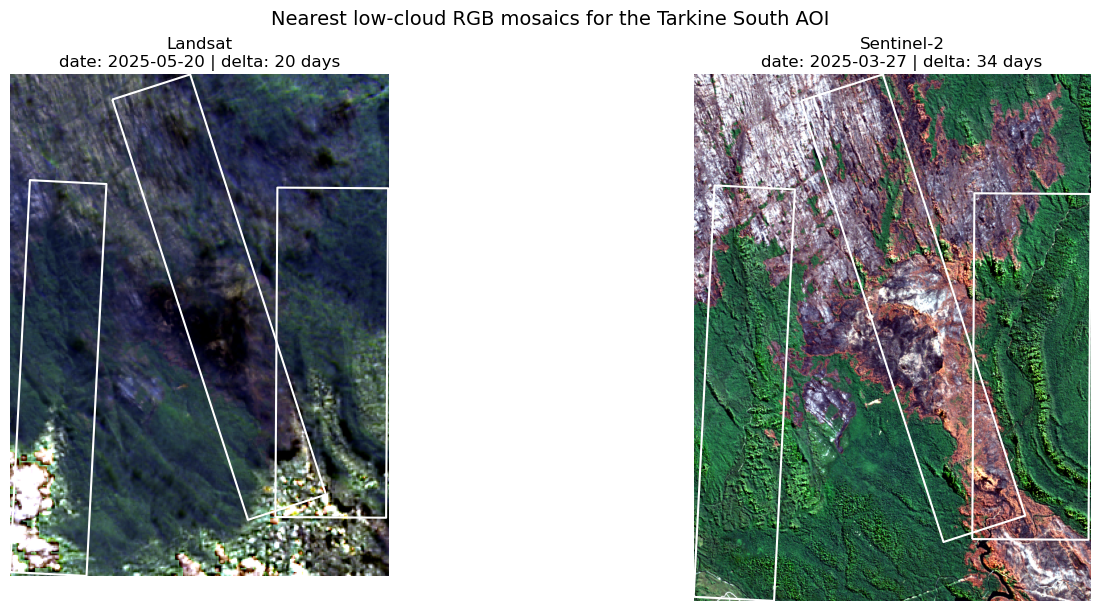

In [12]:
def stretch_rgb(data, lower=2, upper=98):
    stretched = np.zeros_like(data, dtype=np.float32)
    for band_index in range(data.shape[0]):
        band = data[band_index].astype(np.float32)
        valid = band[band > 0]
        if valid.size == 0:
            continue
        lo, hi = np.percentile(valid, [lower, upper])
        if hi <= lo:
            hi = lo + 1
        stretched[band_index] = np.clip((band - lo) / (hi - lo), 0, 1)
    return stretched


def read_preview(path, max_pixels=1400):
    with rasterio.open(path) as src:
        scale = max(1, int(np.ceil(max(src.height, src.width) / max_pixels)))
        preview = src.read(
            out_shape=(
                src.count,
                max(1, src.height // scale),
                max(1, src.width // scale),
            ),
            resampling=Resampling.bilinear,
        )
        extent = (src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top)
        crs = src.crs
    return stretch_rgb(preview), extent, crs


fig, axes = plt.subplots(1, len(mosaic_paths), figsize=(14, 6), constrained_layout=True)
if len(mosaic_paths) == 1:
    axes = [axes]

for ax, (platform_name, mosaic_path) in zip(axes, sorted(mosaic_paths.items())):
    rgb, extent, crs = read_preview(mosaic_path)
    ax.imshow(reshape_as_image(rgb), extent=extent)
    aoi_4326.to_crs(crs).boundary.plot(ax=ax, color="white", linewidth=1.5)

    selection = selections[platform_name]
    title = (
        f"{platform_name.title()}\n"
        f"date: {selection['selected_date'].isoformat()} | "
        f"delta: {selection['days_from_target']} days"
    )
    ax.set_title(title)
    ax.set_axis_off()

fig.suptitle("Nearest low-cloud RGB mosaics for the Tarkine South AOI", fontsize=14)
plt.show()